In [3]:
import tensorflow as tf
from tensorflow import convert_to_tensor, string
from keras.layers import TextVectorization, Embedding, Layer
from tensorflow.data import Dataset
import numpy as np
import matplotlib.pyplot as plt

### Text Vectorization Layer

The text vectorization layer creates a dictionary of words and replaces each word with its corresponding index in the dictionary.

In [12]:
output_sequence_length = 5 # This refers to the number of tokens being generated by the text vectorization for each sentence 
vocab_size = 10
sentences = [["I am a robot"], ["you too robot"]]

In [13]:
sentence_data = Dataset.from_tensor_slices(sentences)

In [14]:
sentence_data

<_TensorSliceDataset element_spec=TensorSpec(shape=(1,), dtype=tf.string, name=None)>

In [15]:
# Create the TextVectorization layer
vectorize_layer = TextVectorization(output_sequence_length=output_sequence_length,max_tokens=vocab_size)
# Train the layer to create a dictionary
vectorize_layer.adapt(sentence_data)
# Convert all sentences to tensors
word_tensors = convert_to_tensor(sentences, dtype=tf.string)
# Use the word tensors to get vectorized phrases
vectorized_words = vectorize_layer(word_tensors)
print("Vocabulary: ", vectorize_layer.get_vocabulary())
print("Vectorized words: ", vectorized_words)

Vocabulary:  ['', '[UNK]', 'robot', 'you', 'too', 'i', 'am', 'a']
Vectorized words:  tf.Tensor(
[[5 6 7 2 0]
 [3 4 2 0 0]], shape=(2, 5), dtype=int64)


### The Embedding Layer

#### Word Embeddings

The Keras Embedding layer converts the integers generated in the text vectorization layer to dense vectors. This layer maps these integers to random numbers, which are later tuned during the training phase.

In [16]:
output_length = 6 # Dimension of the output, so each token/index in the vectorized words is represented as a 6 dimensional vector in space 
word_embedding_layer = Embedding(vocab_size, output_length) 
embedded_words = word_embedding_layer(vectorized_words)
print(embedded_words)

tf.Tensor(
[[[-0.01484957  0.03228874 -0.02998407  0.00775293 -0.0106838
    0.03836915]
  [ 0.02426591  0.01661475 -0.03356417  0.00499756 -0.04954896
    0.00362078]
  [-0.04263948 -0.00296251 -0.0230018  -0.02464541 -0.02047212
    0.01767787]
  [-0.01259413  0.02465072  0.0176747  -0.0316236  -0.04439835
   -0.01710527]
  [-0.00883234  0.01575363 -0.04472117 -0.02253062 -0.02077675
   -0.0404621 ]]

 [[ 0.03557723  0.01720938 -0.00772262 -0.03985773 -0.03358623
   -0.02151458]
  [ 0.04439581 -0.006626   -0.03533704  0.00838383 -0.04964647
   -0.01943598]
  [-0.01259413  0.02465072  0.0176747  -0.0316236  -0.04439835
   -0.01710527]
  [-0.00883234  0.01575363 -0.04472117 -0.02253062 -0.02077675
   -0.0404621 ]
  [-0.00883234  0.01575363 -0.04472117 -0.02253062 -0.02077675
   -0.0404621 ]]], shape=(2, 5, 6), dtype=float32)


In [17]:
embedded_words.shape

TensorShape([2, 5, 6])

#### Position Embeddings

In [21]:
position_embedding_layer = Embedding(output_sequence_length, output_length)
position_indices = tf.range(output_sequence_length)
embedded_indices = position_embedding_layer(position_indices) # output dimension will be 5 x 6 i.e., a 6 dimensional vector representing each pos index
print(embedded_indices)

tf.Tensor(
[[ 0.01951588  0.02985939  0.04115165  0.04652888  0.01682645 -0.02575327]
 [-0.01136287  0.0372399   0.01632111  0.04692504  0.04719409 -0.03224088]
 [-0.04524623  0.01502743 -0.00551412 -0.03903989 -0.00574207 -0.02370292]
 [-0.03316631  0.01470486  0.00109407 -0.04414136  0.0456815   0.00863095]
 [ 0.01126073 -0.04800254  0.04587753  0.02042497  0.00806546 -0.01011883]], shape=(5, 6), dtype=float32)


In [22]:
position_indices = tf.range(output_sequence_length)
position_indices

<tf.Tensor: shape=(5,), dtype=int32, numpy=array([0, 1, 2, 3, 4], dtype=int32)>

#### Output of positional encoding layers in transformers

In [23]:
final_output_embedding = embedded_words + embedded_indices
print("Final output: ", final_output_embedding)

Final output:  tf.Tensor(
[[[ 0.00466632  0.06214813  0.01116758  0.05428181  0.00614266
    0.01261588]
  [ 0.01290304  0.05385464 -0.01724305  0.0519226  -0.00235487
   -0.0286201 ]
  [-0.08788572  0.01206492 -0.02851593 -0.0636853  -0.0262142
   -0.00602505]
  [-0.04576044  0.03935558  0.01876876 -0.07576497  0.00128316
   -0.00847432]
  [ 0.00242839 -0.03224891  0.00115635 -0.00210565 -0.01271129
   -0.05058093]]

 [[ 0.05509311  0.04706877  0.03342904  0.00667115 -0.01675977
   -0.04726785]
  [ 0.03303294  0.0306139  -0.01901593  0.05530887 -0.00245238
   -0.05167686]
  [-0.05784036  0.03967815  0.01216057 -0.07066349 -0.05014042
   -0.04080819]
  [-0.04199865  0.03045849 -0.04362711 -0.06667198  0.02490475
   -0.03183115]
  [ 0.00242839 -0.03224891  0.00115635 -0.00210565 -0.01271129
   -0.05058093]]], shape=(2, 5, 6), dtype=float32)


In [24]:
final_output_embedding.shape

TensorShape([2, 5, 6])

#### Subclassing the Keras Embedding Layer

In [30]:
vectorized_words

<tf.Tensor: shape=(2, 5), dtype=int64, numpy=
array([[5, 6, 7, 2, 0],
       [3, 4, 2, 0, 0]])>

In [33]:
tf.range(tf.shape(vectorized_words)[-1])

<tf.Tensor: shape=(5,), dtype=int32, numpy=array([0, 1, 2, 3, 4], dtype=int32)>

In [28]:
class PositionEmbeddingLayer(Layer):
    def __init__(self, seq_length, vocab_size, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.word_embedding_layer = Embedding(input_dim=vocab_size, output_dim=output_dim)
        self.position_embedding_layer = Embedding(input_dim=seq_length, output_dim=output_dim)

    def call(self, inputs): 
        position_indices = tf.range(tf.shape(inputs)[-1]) # Gives the number of positions present in the input
        embedded_words = self.word_embedding_layer(inputs) # converts the input into a word embedding of dimension 2 x 5 x 6(for each token we get a 6 dimensional embedding)
        embedded_indices = self.position_embedding_layer(position_indices) # Add the positional embedding to the existing word embedding
        return embedded_words + embedded_indices

In [29]:
my_embedding_layer = PositionEmbeddingLayer(output_sequence_length,vocab_size, output_length)
embedded_layer_output = my_embedding_layer(vectorized_words)
print("Output from my_embedded_layer: ", embedded_layer_output)

Output from my_embedded_layer:  tf.Tensor(
[[[-0.03525771  0.03089714 -0.05231044  0.01682333  0.01240444
    0.03978822]
  [-0.04011008  0.0530685  -0.04988374  0.03421259 -0.0581243
   -0.02561822]
  [ 0.01470871 -0.03442864  0.00678066  0.08177304 -0.0149083
    0.02872876]
  [ 0.03388891 -0.02499773  0.01320301 -0.04235512  0.0158781
    0.05622227]
  [ 0.02938583 -0.05460336  0.02195152 -0.04825564 -0.01652721
    0.04704913]]

 [[-0.00023553  0.00880669 -0.01219593 -0.00926071  0.02373952
    0.07570148]
  [ 0.00132442  0.03849939 -0.05942004 -0.02309139 -0.0260712
   -0.03577949]
  [ 0.01024231 -0.0520383   0.02796143  0.03133054  0.06270508
    0.03903923]
  [ 0.0578352  -0.04519593  0.00191985 -0.04831471 -0.03334183
    0.05880109]
  [ 0.02938583 -0.05460336  0.02195152 -0.04825564 -0.01652721
    0.04704913]]], shape=(2, 5, 6), dtype=float32)


### Visualization of the final embedding

In [42]:
class PositionEmbeddingFixedWeights(Layer):
    def __init__(self, seq_length, vocab_size, output_dim, **kwargs):
        super().__init__(**kwargs)
        word_embedding_matrix = self.get_position_encoding(vocab_size, output_dim)
        pos_embedding_matrix = self.get_position_encoding(seq_length, output_dim)
        self.word_embedding_layer = Embedding(input_dim=vocab_size, output_dim=output_dim,weights=[word_embedding_matrix],trainable=False)
        self.position_embedding_layer = Embedding(input_dim=seq_length, output_dim=output_dim,weights=[pos_embedding_matrix],trainable=False)
    
    def get_position_encoding(self, seq_len, d, n=10000):
        P = np.zeros((seq_len, d))
        for k in range(seq_len):
            for i in np.arange(int(d/2)):
                denominator = np.power(n, 2*i/d)
                P[k, 2*i] = np.sin(k/denominator)
                P[k, 2*i+1] = np.cos(k/denominator)
        return P
    
    
    def call(self, inputs):
        position_indices = tf.range(tf.shape(inputs)[-1])
        embedded_words = self.word_embedding_layer(inputs)
        embedded_indices = self.position_embedding_layer(position_indices)
        return embedded_words + embedded_indices

In [43]:
attnisallyouneed_embedding = PositionEmbeddingFixedWeights(output_sequence_length,vocab_size, output_length)
attnisallyouneed_output = attnisallyouneed_embedding(vectorized_words)
print("Output from my_embedded_layer: ", attnisallyouneed_output)

Output from my_embedded_layer:  tf.Tensor(
[[[-0.9589243   1.2836622   0.23000172  1.9731903   0.01077196
    1.9999421 ]
  [ 0.56205547  1.5004725   0.3213085   1.9603932   0.01508068
    1.9999142 ]
  [ 1.566284    0.3377554   0.41192317  1.9433732   0.01938933
    1.999877  ]
  [ 1.0504174  -1.4061394   0.2314966   1.9860148   0.01077211
    1.9999698 ]
  [-0.7568025   0.3463564   0.18459873  1.982814    0.00861763
    1.9999628 ]]

 [[ 0.14112     0.0100075   0.1387981   1.9903207   0.00646326
    1.9999791 ]
  [ 0.08466846 -0.11334133  0.23099795  1.9817369   0.01077207
    1.9999605 ]
  [ 1.8185948  -0.8322937   0.185397    1.9913884   0.00861771
    1.9999814 ]
  [ 0.14112     0.0100075   0.1387981   1.9903207   0.00646326
    1.9999791 ]
  [-0.7568025   0.3463564   0.18459873  1.982814    0.00861763
    1.9999628 ]]], shape=(2, 5, 6), dtype=float32)


In [45]:
technical_phrase = "to understand machine learning algorithms you need" +\
" to understand concepts such as gradient of a function "+\
"Hessians of a matrix and optimization etc"
wise_phrase = "patrick henry said give me liberty or give me death "+\
"when he addressed the second virginia convention in march"

In [46]:
total_vocabulary = 200
seq_length = 20
final_output_len = 50

In [47]:
phrase_vectorization_layer = TextVectorization(output_sequence_length=seq_length, max_tokens=total_vocabulary)

In [48]:
# Learn the dictionary
phrase_vectorization_layer.adapt([technical_phrase, wise_phrase])

In [49]:
# Convert all sentences to tensors
phrase_tensors = convert_to_tensor([technical_phrase, wise_phrase],dtype=tf.string)

In [50]:
phrase_tensors

<tf.Tensor: shape=(2,), dtype=string, numpy=
array([b'to understand machine learning algorithms you need to understand concepts such as gradient of a function Hessians of a matrix and optimization etc',
       b'patrick henry said give me liberty or give me death when he addressed the second virginia convention in march'],
      dtype=object)>

In [51]:
vectorized_phrases = phrase_vectorization_layer(phrase_tensors)

In [52]:
vectorized_phrases

<tf.Tensor: shape=(2, 20), dtype=int64, numpy=
array([[ 3,  2, 21, 23, 36,  8, 18,  3,  2, 33, 12, 34, 28,  4,  7, 29,
        25,  4,  7, 19],
       [15, 26, 14,  6,  5, 22, 16,  6,  5, 31,  9, 27, 37, 11, 13, 10,
        32, 24, 20,  0]])>

In [53]:
# Use the word tensors to get vectorized phrases
random_weights_embedding_layer = PositionEmbeddingLayer(seq_length,total_vocabulary,final_output_len)
fixed_weights_embedding_layer = PositionEmbeddingFixedWeights(seq_length,total_vocabulary,final_output_len)
random_embedding = random_weights_embedding_layer(vectorized_phrases)
fixed_embedding = fixed_weights_embedding_layer(vectorized_phrases)

In [56]:
random_embedding

<tf.Tensor: shape=(2, 20, 50), dtype=float32, numpy=
array([[[ 0.04642049, -0.04158642,  0.07623944, ..., -0.01152316,
         -0.00491584, -0.06906185],
        [ 0.01110074,  0.02589196, -0.01927759, ...,  0.05063567,
         -0.02998346, -0.0407936 ],
        [-0.01607037, -0.05321804, -0.03930108, ..., -0.02584335,
          0.04558984,  0.08623094],
        ...,
        [ 0.06587527,  0.02030142,  0.00915423, ..., -0.01859859,
         -0.01800357, -0.00069413],
        [-0.00618937, -0.02543439, -0.01270768, ..., -0.05461296,
         -0.01761964,  0.08832606],
        [-0.0373837 ,  0.01781171,  0.05241786, ..., -0.07164019,
          0.00096258, -0.0506347 ]],

       [[ 0.09419078,  0.0549557 ,  0.01477433, ..., -0.04042263,
          0.06445642, -0.05752509],
        [ 0.00506138, -0.04976625,  0.01789626, ..., -0.01198762,
         -0.02950449, -0.0898008 ],
        [-0.03864795, -0.01884079, -0.03550949, ...,  0.01439295,
          0.01455285, -0.00599461],
        ...,
 

In [57]:
random_embedding.shape # So what is happening is from the given sentences we are generating 20 tokens for each sentence and each token is represented as a vector of 50 dimensions in space

TensorShape([2, 20, 50])

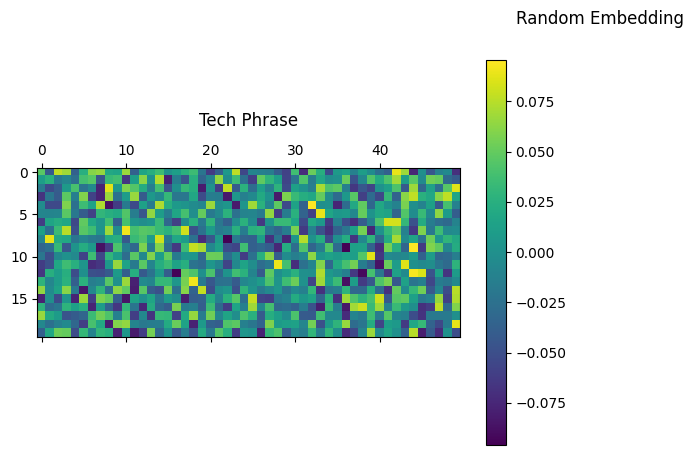

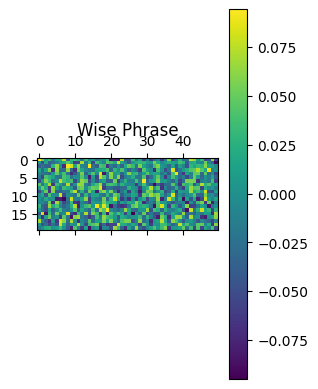

In [54]:
fig = plt.figure(figsize=(15, 5))
title = ["Tech Phrase", "Wise Phrase"]
for i in range(2):
    ax = plt.subplot(1, 2, 1+i)
    matrix = tf.reshape(random_embedding[i, :, :], (seq_length, final_output_len))
    cax = ax.matshow(matrix)
    plt.gcf().colorbar(cax)
    plt.title(title[i], y=1.2)
    fig.suptitle("Random Embedding")
    plt.show()

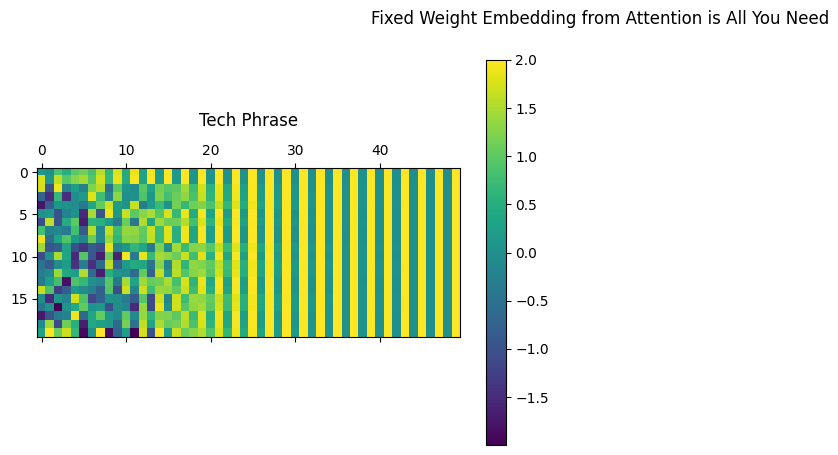

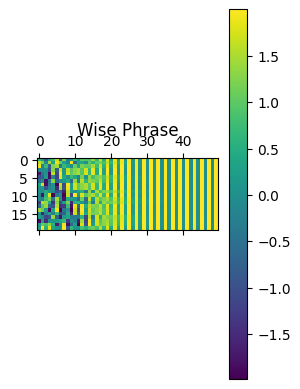

In [60]:
fig = plt.figure(figsize=(15, 5))
title = ["Tech Phrase", "Wise Phrase"]
for i in range(2):
    ax = plt.subplot(1, 2, 1+i)
    matrix = tf.reshape(fixed_embedding[i, :, :], (seq_length, final_output_len))
    cax = ax.matshow(matrix)
    plt.gcf().colorbar(cax)
    plt.title(title[i], y=1.2)
    fig.suptitle("Fixed Weight Embedding from Attention is All You Need")
    plt.show()